# EEG Feature Extraction and Visualization - Tutorial

This notebook demonstrates how to use the comprehensive feature extraction and visualization tools.

## Features Extracted:
- **Temporal**: Statistical measures, Hjorth parameters, zero-crossing rate, RMS
- **Spectral**: Band powers (delta, theta, alpha, beta, gamma), spectral entropy, dominant frequency
- **Functional**: Correlation-based connectivity, Phase Locking Value (PLV)

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech


## Step 2: Explore the Features DataFrame

In [3]:
# Display first few rows
import os
df_features_path = "/Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/processed/comprehensive_features_subjects.csv"
if os.path.exists(df_features_path):
    df_features = pd.read_csv(df_features_path)
    print(f"✓ Loaded comprehensive features from {df_features_path} ({len(df_features)} rows)")

print(df_features.head())

/var/folders/nf/98xxwv1511dfz5j4f3x3jqgc0000gn/T/ipykernel_3159/4266007178.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_features = pd.read_csv(df_features_path)


✓ Loaded comprehensive features from /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/processed/comprehensive_features_subjects.csv (2361066 rows)
  subject_id  session_id  epoch_idx channel label_name  temp_mean  temp_std  \
0          0           1          0    EEG1  mille_img  -0.613480  4.154372   
1          0           1          0    EEG2  mille_img   0.746971  4.536037   
2          0           1          0    EEG3  mille_img  -0.301763  6.297506   
3          0           1          0    EEG4  mille_img  -0.777701  5.034784   
4          0           1          0    EEG5  mille_img   0.268468  5.468369   

    temp_var   temp_min   temp_max  ...  spec_dominant_freq  \
0  17.258806 -14.659428   9.279803  ...                 1.0   
1  20.575635 -12.214738  14.713585  ...                 1.0   
2  39.658577 -17.399109  18.833666  ...                 1.0   
3  25.349052 -20.848421  14.568258  ...                 1.0   
4  29.903057 -15.651170  14.500707  

In [4]:
# Display feature categories
temporal_features = [col for col in df_features.columns if col.startswith('temp_')]
spectral_features = [col for col in df_features.columns if col.startswith('spec_')]
functional_features = [col for col in df_features.columns if col.startswith('func_')]

print(f"Temporal features ({len(temporal_features)}): {temporal_features}")
print(f"\nSpectral features ({len(spectral_features)}): {spectral_features}")
print(f"\nFunctional features ({len(functional_features)}): {functional_features}")

Temporal features (14): ['temp_mean', 'temp_std', 'temp_var', 'temp_min', 'temp_max', 'temp_range', 'temp_ptp', 'temp_skewness', 'temp_kurtosis', 'temp_rms', 'temp_zcr', 'temp_hjorth_activity', 'temp_hjorth_mobility', 'temp_hjorth_complexity']

Spectral features (20): ['spec_delta', 'spec_delta_rel', 'spec_theta', 'spec_theta_rel', 'spec_alpha', 'spec_alpha_rel', 'spec_beta', 'spec_beta_rel', 'spec_gamma', 'spec_gamma_rel', 'spec_total_power', 'spec_alpha_beta_ratio', 'spec_theta_alpha_ratio', 'spec_theta_beta_ratio', 'spec_edge_freq', 'spec_entropy', 'spec_dominant_freq', 'spec_dominant_power', 'spec_mean_freq', 'spec_median_freq']

Functional features (6): ['func_mean_corr', 'func_max_corr', 'func_std_corr', 'func_num_strong_conn', 'func_mean_plv', 'func_max_plv']


In [5]:
# Summary statistics
print("Dataset Summary:")
print(f"Number of subjects: {df_features['subject_id'].nunique()}")
print(f"Number of sessions: {df_features['session_id'].nunique()}")
print(f"Number of epochs: {df_features['epoch_idx'].nunique()}")
print(f"Number of channels: {df_features['channel'].nunique()}")
print(f"Number of labels: {df_features['label_name'].nunique()}")
print(f"\nTotal feature vectors: {len(df_features)}")

Dataset Summary:
Number of subjects: 76
Number of sessions: 7
Number of epochs: 144
Number of channels: 61
Number of labels: 110

Total feature vectors: 2361066


In [23]:
# Elenca i soggetti che hanno registrazioni alla sessione 7
n=5
mask = df_features['session_id'] == n
subjects_sess7 = df_features.loc[mask, 'subject_id'].unique()

print(f"Soggetti con session_id == 7 ({len(subjects_sess7)}):")
print(list(subjects_sess7))

# Riepilogo per soggetto: numero di epoch, numero di canali e righe presenti per la sessione 7
summary_sess7 = (
    df_features[mask]
    .groupby('subject_id')
    .agg(
        epochs=('epoch_idx', 'nunique'),
        channels=('channel', 'nunique'),
        rows=('subject_id', 'size')
    )
    .sort_values(['epochs', 'channels', 'rows'], ascending=False)
)

print(f"\nRiepilogo per soggetto (epochs, channels, rows) per session_id == {n}:")
print(summary_sess7)

Soggetti con session_id == 7 (64):
[0, 1, 2, 3, 4, 6, 7, 9, 10, 11, 12, 13, 14, 17, 18, 19, 20, 22, 23, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, '72']

Riepilogo per soggetto (epochs, channels, rows) per session_id == 5:
            epochs  channels  rows
subject_id                        
0              110        61  6710
1              110        61  6710
2              110        61  6710
3              110        61  6710
4              110        61  6710
...            ...       ...   ...
71             110        61  6710
6               94        61  5734
72              67        61  4050
72              44        61  2660
18              22        61  1342

[64 rows x 3 columns]


## Step 3: Basic Feature Analysis

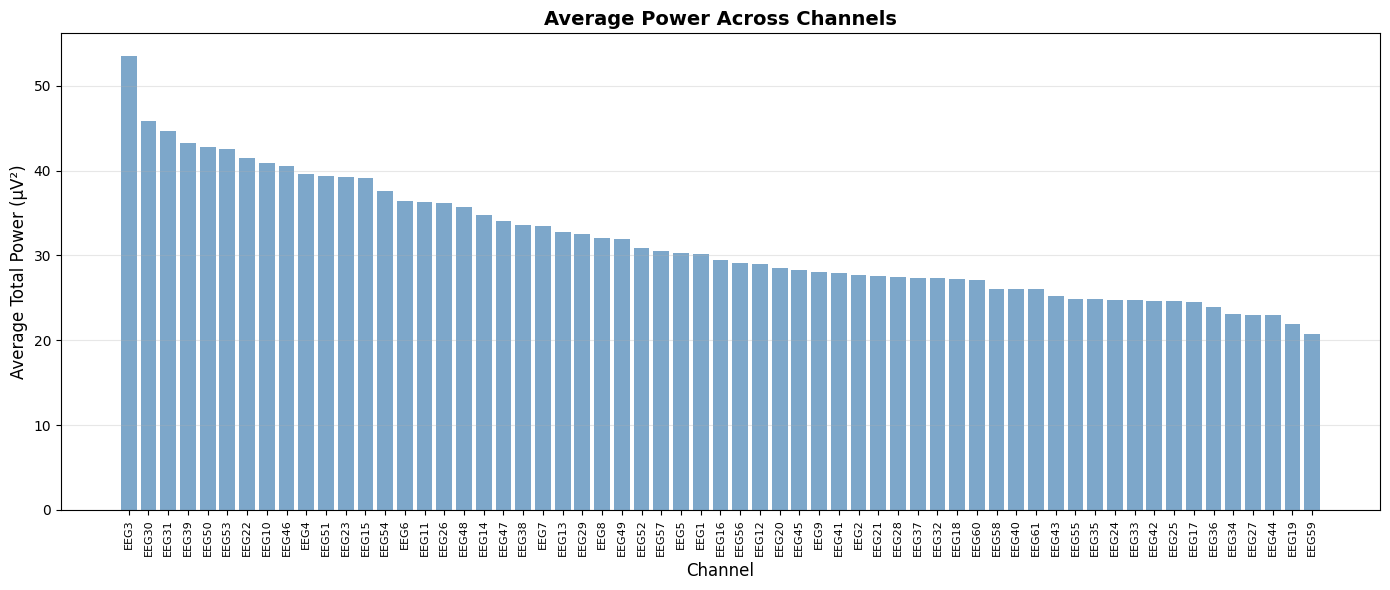


Top 10 highest power channels:
channel
EEG3     53.519789
EEG30    45.873236
EEG31    44.625656
EEG39    43.244080
EEG50    42.752421
EEG53    42.530715
EEG22    41.451186
EEG10    40.934934
EEG46    40.510368
EEG4     39.589157
Name: spec_total_power, dtype: float64


In [24]:
# Analyze power distribution across channels
channel_avg_power = df_features.groupby('channel')['spec_total_power'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(range(len(channel_avg_power)), channel_avg_power.values, color='steelblue', alpha=0.7)
plt.xticks(range(len(channel_avg_power)), channel_avg_power.index, rotation=90, fontsize=8)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Average Total Power (µV²)', fontsize=12)
plt.title('Average Power Across Channels', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nTop 10 highest power channels:")
print(channel_avg_power.head(10))

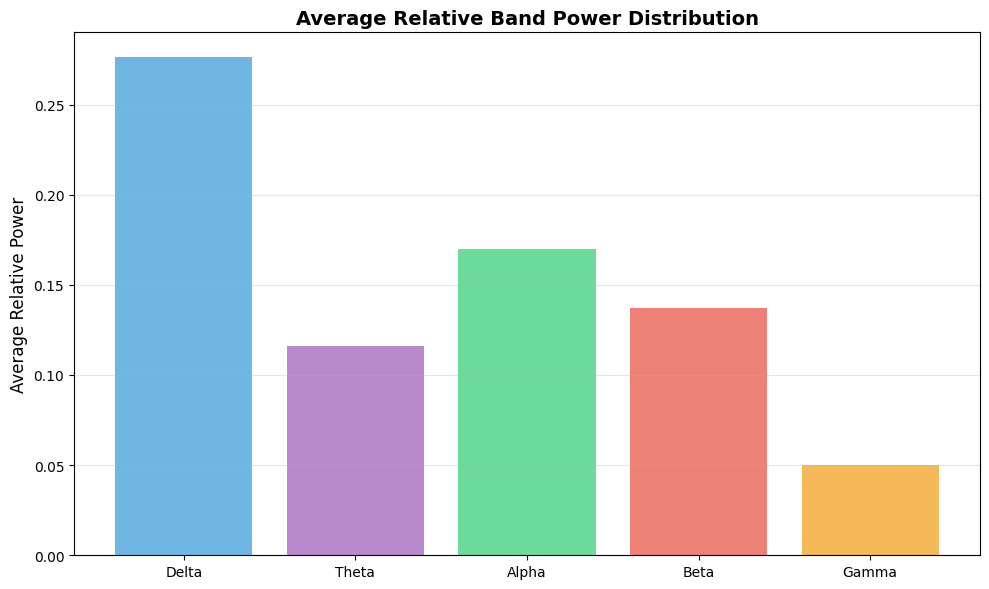

In [25]:
# Compare band powers
band_cols = ['spec_delta_rel', 'spec_theta_rel', 'spec_alpha_rel', 'spec_beta_rel', 'spec_gamma_rel']
band_averages = df_features[band_cols].mean()

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#9b59b6', '#2ecc71', '#e74c3c', '#f39c12']
plt.bar(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'], band_averages.values, color=colors, alpha=0.7)
plt.ylabel('Average Relative Power', fontsize=12)
plt.title('Average Relative Band Power Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Step 4: Generate Visualizations

In [26]:
# Import visualization functions
from scripts.graphs.feature_visualizations import (
    plot_electrode_power_across_epochs,
    plot_top_electrodes_per_epoch,
    plot_feature_distributions,
    plot_feature_correlation_matrix
)

# Create output directory
output_dir = project_root / "figures" / "feature_visualizations"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving visualizations to: {output_dir}")

Saving visualizations to: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/figures/feature_visualizations


In [27]:
# Visualization 1: Single electrode power variation
subject_id = df_features['subject_id'].iloc[0]
electrode = 'Cz'  # Central electrode

if electrode in df_features['channel'].values:
    plot_electrode_power_across_epochs(
        df_features, 
        electrode=electrode, 
        subject_id=subject_id,
        output_path=output_dir / f"power_variation_{electrode}.png"
    )
    print(f"✓ Created power variation plot for {electrode}")

In [28]:
# Visualization 2: Top electrodes per epoch
plot_top_electrodes_per_epoch(
    df_features, 
    subject_id=subject_id, 
    top_n=5,
    output_path=output_dir / "top_electrodes_per_epoch.png"
)
print("✓ Created top electrodes heatmap")

Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/figures/feature_visualizations/top_electrodes_per_epoch.png
✓ Created top electrodes heatmap


In [29]:
# Visualization 3: Feature distributions
plot_feature_distributions(
    df_features, 
    output_path=output_dir / "feature_distributions.png"
)
print("✓ Created feature distribution plots")

Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/figures/feature_visualizations/feature_distributions.png
✓ Created feature distribution plots


In [30]:
# Visualization 4: Feature correlation matrix
plot_feature_correlation_matrix(
    df_features, 
    output_path=output_dir / "feature_correlation_matrix.png"
)
print("✓ Created feature correlation matrix")

Saved: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/figures/feature_visualizations/feature_correlation_matrix.png
✓ Created feature correlation matrix


## Step 5: Advanced Analysis - Label Comparison

/var/folders/nf/98xxwv1511dfz5j4f3x3jqgc0000gn/T/ipykernel_54601/261772484.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_to_plot, labels=labels_to_compare)
/var/folders/nf/98xxwv1511dfz5j4f3x3jqgc0000gn/T/ipykernel_54601/261772484.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_to_plot, labels=labels_to_compare)
/var/folders/nf/98xxwv1511dfz5j4f3x3jqgc0000gn/T/ipykernel_54601/261772484.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_to_plot, labels=labels_to_compare)
/var/folders/nf/98xxwv1511dfz5j4f3x3jqgc0000gn/T/ipykernel_54601/26177248

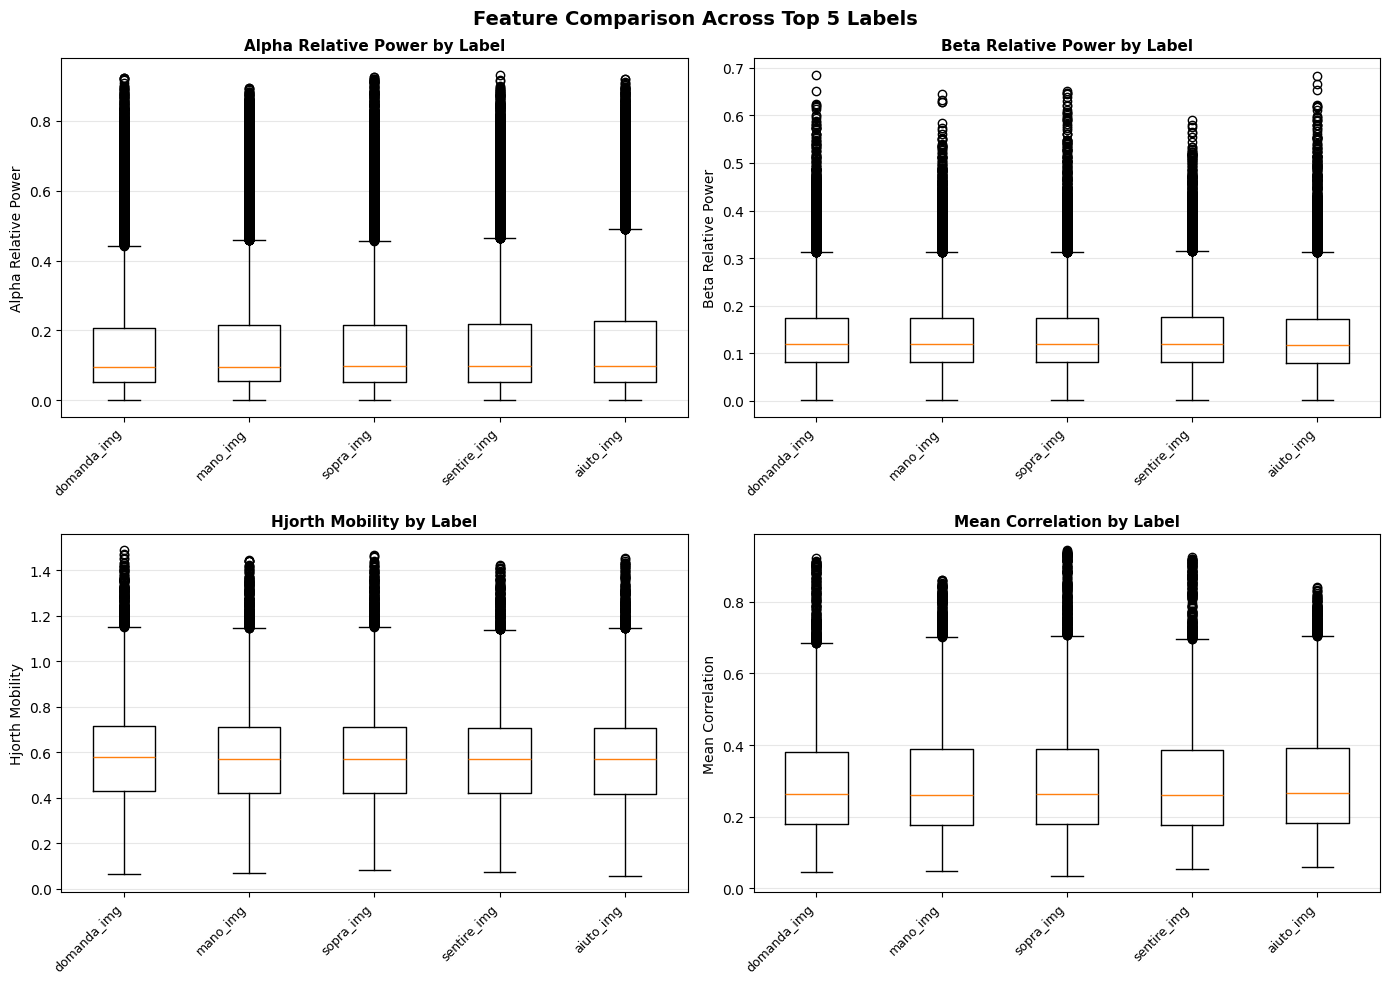

✓ Created label comparison plot


In [31]:
# Compare features across different labels
labels_to_compare = df_features['label_name'].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

features_to_plot = [
    ('spec_alpha_rel', 'Alpha Relative Power'),
    ('spec_beta_rel', 'Beta Relative Power'),
    ('temp_hjorth_mobility', 'Hjorth Mobility'),
    ('func_mean_corr', 'Mean Correlation')
]

for i, (feat, title) in enumerate(features_to_plot):
    if feat in df_features.columns:
        data_to_plot = [df_features[df_features['label_name'] == label][feat].dropna().values 
                       for label in labels_to_compare]
        
        axes[i].boxplot(data_to_plot, labels=labels_to_compare)
        axes[i].set_ylabel(title, fontsize=10)
        axes[i].set_xticklabels(labels_to_compare, rotation=45, ha='right', fontsize=9)
        axes[i].set_title(f'{title} by Label', fontsize=11, fontweight='bold')
        axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Feature Comparison Across Top 5 Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / "label_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("✓ Created label comparison plot")

## Step 6: Export Summary Report

In [32]:
# Create a summary report
summary = {
    'Dataset Info': {
        'Total Subjects': df_features['subject_id'].nunique(),
        'Total Sessions': df_features['session_id'].nunique(),
        'Total Epochs': df_features['epoch_idx'].nunique(),
        'Total Channels': df_features['channel'].nunique(),
        'Total Labels': df_features['label_name'].nunique(),
        'Total Feature Vectors': len(df_features)
    },
    'Feature Counts': {
        'Temporal Features': len(temporal_features),
        'Spectral Features': len(spectral_features),
        'Functional Features': len(functional_features),
        'Total Features': len(temporal_features) + len(spectral_features) + len(functional_features)
    },
    'Average Power Statistics': {
        'Mean Total Power': df_features['spec_total_power'].mean(),
        'Std Total Power': df_features['spec_total_power'].std(),
        'Max Total Power': df_features['spec_total_power'].max(),
        'Min Total Power': df_features['spec_total_power'].min()
    },
    'Band Power Averages': {
        'Delta': df_features['spec_delta_rel'].mean(),
        'Theta': df_features['spec_theta_rel'].mean(),
        'Alpha': df_features['spec_alpha_rel'].mean(),
        'Beta': df_features['spec_beta_rel'].mean(),
        'Gamma': df_features['spec_gamma_rel'].mean()
    }
}

# Print summary
import json
print(json.dumps(summary, indent=2))

# Save to file
with open(output_dir / 'feature_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✓ Summary saved to {output_dir / 'feature_summary.json'}")

{
  "Dataset Info": {
    "Total Subjects": 76,
    "Total Sessions": 7,
    "Total Epochs": 144,
    "Total Channels": 61,
    "Total Labels": 110,
    "Total Feature Vectors": 2361066
  },
  "Feature Counts": {
    "Temporal Features": 14,
    "Spectral Features": 20,
    "Functional Features": 6,
    "Total Features": 40
  },
  "Average Power Statistics": {
    "Mean Total Power": 31.570130504794317,
    "Std Total Power": 65.45324183123788,
    "Max Total Power": 12599.25350576556,
    "Min Total Power": 0.3948781168491685
  },
  "Band Power Averages": {
    "Delta": 0.27621949663602047,
    "Theta": 0.11618878921982001,
    "Alpha": 0.16959192946955262,
    "Beta": 0.13723739904208793,
    "Gamma": 0.04988793955327735
  }
}

✓ Summary saved to /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/figures/feature_visualizations/feature_summary.json


## Conclusion

This notebook demonstrated:
1. ✅ Feature extraction from EEG data (temporal, spectral, functional)
2. ✅ Creating a unified features dataframe
3. ✅ Visualizing power variations across electrodes and epochs
4. ✅ Identifying high-power electrodes
5. ✅ Comparing features across different labels
6. ✅ Analyzing feature distributions and correlations

All visualizations are saved in: `figures/feature_visualizations/`